In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
price_df = pd.read_csv(
    "../dataset/processed/realestate_features.csv"
)


geo_df = pd.read_csv(
    "../dataset/processed/geo_risk_features.csv"
)


print("Price Dataset:", price_df.shape)
print("Geo Dataset:", geo_df.shape)

Price Dataset: (13859, 22)
Geo Dataset: (13859, 26)


In [3]:
recommendation_df = geo_df[
    [
        "price",
        "geo_risk_score",
        "location_rating",
        "grade_of_the_house",
        "number_of_bedrooms",
        "number_of_bathrooms",
        "living_area"
    ]
]


recommendation_df.head()

,price,geo_risk_score,location_rating,grade_of_the_house,number_of_bedrooms,number_of_bathrooms,living_area
0,838000,0.292711,Low Risk,9,4,2.50,3310
1,805000,0.008455,Low Risk,8,3,2.00,2710
2,790000,0.003790,Low Risk,9,3,2.50,2600
3,785000,0.585423,Medium Risk,10,5,3.25,3660
4,750000,0.294169,Low Risk,8,3,1.75,2240


In [4]:
recommendation_df["investment_score"] = (

    recommendation_df["geo_risk_score"] * 40

    +

    (recommendation_df["grade_of_the_house"] / 10) * 30

    +

    (recommendation_df["living_area"] /
     recommendation_df["living_area"].max()) * 20

    +

    (recommendation_df["number_of_bedrooms"] / 10) * 10

)


recommendation_df.head()

,price,geo_risk_score,location_rating,grade_of_the_house,number_of_bedrooms,number_of_bathrooms,living_area,investment_score
0,838000,0.292711,Low Risk,9,4,2.50,3310,51.558722
1,805000,0.008455,Low Risk,8,3,2.00,2710,34.584182
2,790000,0.003790,Low Risk,9,3,2.50,2600,37.103475
3,785000,0.585423,Medium Risk,10,5,3.25,3660,68.203006
4,750000,0.294169,Low Risk,8,3,1.75,2240,44.756069


In [5]:
def investment_label(score):

    if score >= 60:
        return "High Investment Potential"

    elif score >= 35:
        return "Moderate Investment"

    else:
        return "Low Investment"


recommendation_df["investment_recommendation"] = (
    recommendation_df["investment_score"]
    .apply(investment_label)
)


recommendation_df[
    [
        "investment_score",
        "investment_recommendation"
    ]
].head()

,investment_score,investment_recommendation
0,51.558722,Moderate Investment
1,34.584182,Low Investment
2,37.103475,Moderate Investment
3,68.203006,High Investment Potential
4,44.756069,Moderate Investment


In [6]:
recommendation_df[
    "investment_recommendation"
].value_counts()

investment_recommendation
Moderate Investment          8386
Low Investment               5189
High Investment Potential     284
Name: count, dtype: int64

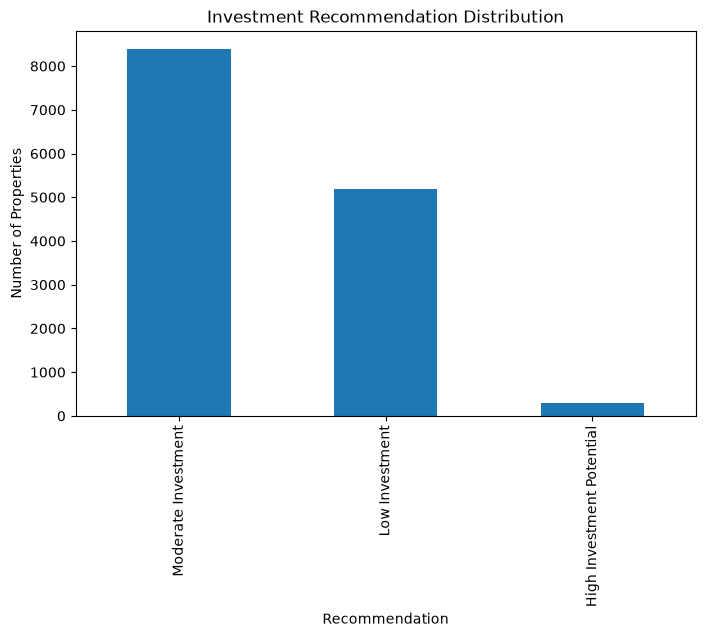

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

recommendation_df[
    "investment_recommendation"
].value_counts().plot(
    kind="bar"
)

plt.title(
    "Investment Recommendation Distribution"
)

plt.xlabel(
    "Recommendation"
)

plt.ylabel(
    "Number of Properties"
)

plt.show()

In [8]:
import os

os.makedirs(
    "../dataset/processed",
    exist_ok=True
)


recommendation_df.to_csv(
    "../dataset/processed/investment_recommendations.csv",
    index=False
)


print("Investment Recommendation Dataset Saved Successfully!")

Investment Recommendation Dataset Saved Successfully!


In [9]:
import joblib
import os

os.makedirs(
    "../models",
    exist_ok=True
)


joblib.dump(
    investment_label,
    "../models/investment_recommendation.pkl"
)


print("Recommendation Logic Saved!")

Recommendation Logic Saved!
